In [26]:
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import re

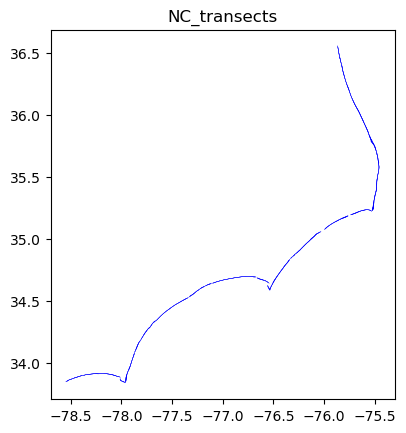

In [14]:
# plot gdf
gdf = gpd.read_file('Required_NC_Transects.geojson')

gdf.plot(color='blue')

plt.title("NC_transects")
plt.show()

In [48]:
# find variance for each transect
ids = gpd.read_file('Required_NC_Transects.geojson')['id']
variance_list = []

for id in ids:
    # load individual csv
    df = pd.read_csv(f'NC_CoastSat_Shorelines/{id}.csv', header=None)
    
    #e xtract dates from str
    df['clean_time'] = df.iloc[:, 0].astype(str).str.extract(r'(\d{4}-\d{2}-\d{2} \d{2}:\d{2}:\d{2})')

    # convert to datetime
    df['clean_time'] = pd.to_datetime(df['clean_time'])
    
    # get differences
    diff_days = df['clean_time'].diff().dt.total_seconds() / (24 * 3600)

    # calculate variance
    variance = diff_days.var()

    # add to list
    variance_list.append(variance)

# make variance dataframe
variance_df = pd.DataFrame({
    'id': ids,
    'variance': variance_list
})

print(variance_df.head())

                 id     variance
0  usa_NC_0022_0120   470.004957
1  usa_NC_0031_0128   763.426744
2  usa_NC_0042_0101   614.192976
3  usa_NC_0008_0139  1166.641399
4  usa_NC_0019_0068   709.977451


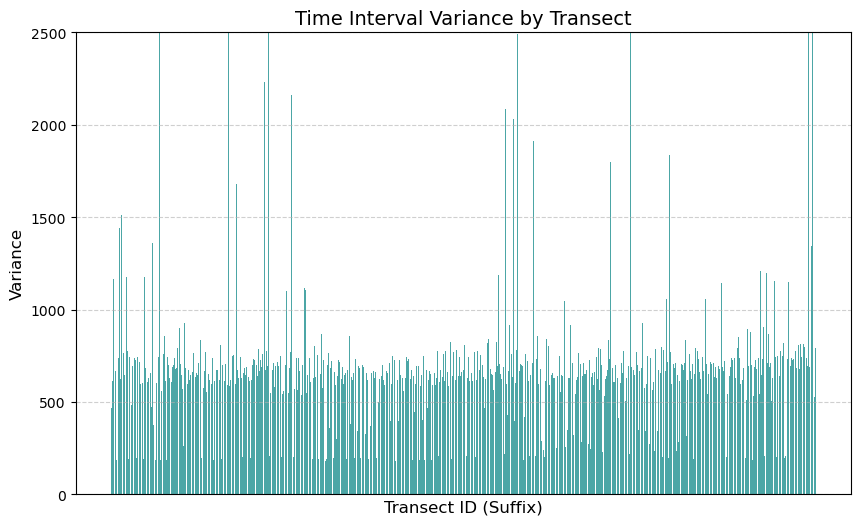

In [63]:
# plot variance to determine cutoff
variance_df['short_id'] = variance_df['id'].astype(str).str[-9:]

plt.figure(figsize=(10, 6))
plt.bar(variance_df['short_id'], variance_df['variance'], color='teal', alpha=0.7)

plt.xlabel('Transect ID (Suffix)', fontsize=12)
plt.ylabel('Variance', fontsize=12)
plt.ylim([0,2500])
plt.xticks([])
plt.title('Time Interval Variance by Transect', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.6)

# plt.tight_layout()
plt.show()

In [70]:
# make list of ids with above threshold variance
ids_bad = variance_df[variance_df['variance'] > 1000]['id']
ids_bad = sorted(ids_bad)
print(ids_bad)

['usa_NC_0001_0030', 'usa_NC_0001_0050', 'usa_NC_0001_0120', 'usa_NC_0002_0170', 'usa_NC_0003_0002', 'usa_NC_0003_0250', 'usa_NC_0004_0002', 'usa_NC_0004_0012', 'usa_NC_0007_0130', 'usa_NC_0007_0140', 'usa_NC_0008_0009', 'usa_NC_0008_0019', 'usa_NC_0008_0029', 'usa_NC_0008_0039', 'usa_NC_0008_0049', 'usa_NC_0008_0059', 'usa_NC_0008_0069', 'usa_NC_0008_0079', 'usa_NC_0008_0089', 'usa_NC_0008_0099', 'usa_NC_0008_0109', 'usa_NC_0008_0119', 'usa_NC_0008_0129', 'usa_NC_0008_0139', 'usa_NC_0008_0149', 'usa_NC_0008_0159', 'usa_NC_0008_0169', 'usa_NC_0008_0179', 'usa_NC_0008_0189', 'usa_NC_0008_0199', 'usa_NC_0008_0209', 'usa_NC_0008_0219', 'usa_NC_0008_0229', 'usa_NC_0008_0239', 'usa_NC_0009_0141', 'usa_NC_0010_0140', 'usa_NC_0011_0128', 'usa_NC_0011_0137', 'usa_NC_0012_0141', 'usa_NC_0014_0001', 'usa_NC_0018_0197', 'usa_NC_0020_0360', 'usa_NC_0022_0080', 'usa_NC_0024_0271', 'usa_NC_0025_0013', 'usa_NC_0025_0023', 'usa_NC_0027_0201', 'usa_NC_0027_0211', 'usa_NC_0027_0221', 'usa_NC_0027_0231',